In [ ]:
from math import exp
import copy
import numpy as np
import matplotlib.pyplot as plt
from operator import attrgetter

## Nonstationary Bandit Environment

In [2]:
# Gaussian Process with Radial Basis Function Kernel
def rbf_kernel(x1, x2, variance = 1):
    return exp(-1 * ((x1-x2) ** 2) / (2*variance))

def gram_matrix(xs,var):
    return [[rbf_kernel(x1,x2,variance=var) for x2 in xs] for x1 in xs]

def generate_mean_rewards(n_arms=5,smoothness=1):
    xs = np.arange(0, 5, 0.025)
    mean = [0 for x in xs]
    gram = gram_matrix(xs, var=smoothness)
        
    all_mean_rewards = []
    for i in range(n_arms):
        mus = np.random.multivariate_normal(mean, gram)
        all_mean_rewards.append(mus)
    return np.vstack(all_mean_rewards)

def generate_rewards(mean_rewards, noise_var=1):
    rewards = mean_rewards + np.random.normal(0,np.sqrt(noise_var),size=mean_rewards.shape)
    return rewards

## Examining the Nonstationary Environment

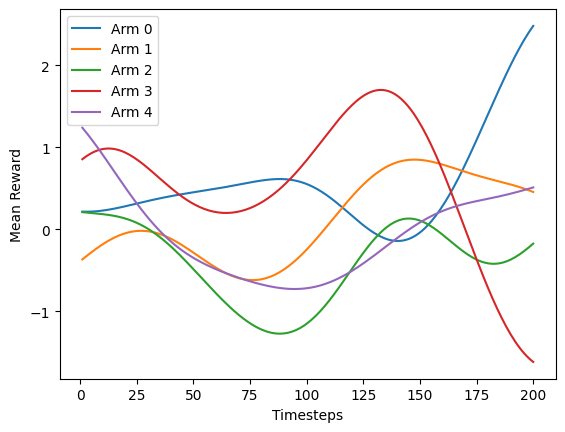

In [3]:
mean_rewards = generate_mean_rewards(smoothness=1)
plt.figure()
for k in range(len(mean_rewards)):
    plt.plot(np.arange(1,len(mean_rewards[k])+1), mean_rewards[k], label='Arm {}'.format(k))
plt.ylabel('Mean Reward')
plt.xlabel('Timesteps')
plt.legend()
plt.show()

## Generating Rewards

In [4]:
rewards = generate_rewards(mean_rewards, noise_var=1)

## Solutions

### (b)

In [5]:
# Simplify and adapt the Arm class and GetArms function to be suitable for this environment
class Arm:
    def __init__(self, index, mu_t_a, sigma):
        self.index = index
        self.numplays = 0.0
        self.mu_t_a = mu_t_a
        self.sigma = sigma
        self.totrew = 0.0
        self.avgrew = 0.0

    def sample(self, t):
        return self.mu_t_a[t] + np.random.normal(0, np.sqrt(1))

    def update(self, rew):
        self.numplays += 1
        self.totrew += rew
        self.avgrew = self.totrew / self.numplays

    def play(self, t):
        rew = self.sample(t)
        self.update(rew)
        return rew

def GetArms(K, mu_t, sigma):
    arms = []
    for i in range(K):
        arms.append(Arm(i, mu_t[i], sigma))
    return arms

In [6]:
def UpdateCBs(arm, T, K):
    cb = np.sqrt(2 * arm.sigma * (np.log(T * K)) / arm.numplays)
    arm.ucb = arm.avgrew + cb
    arm.lcb = arm.avgrew - cb

def UpperConfidenceBound(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    for arm in arms:
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1
        if t == T:
            break

    while t < T:
        arm = max(arms, key=attrgetter('ucb'))
        rew[t] = arm.play(t)
        reg[t] = max(arm_2.mu_t_a[t] for arm_2 in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1

    return rew, reg

In [7]:
def ThompsonSampling_Gaussian(arms, priors, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    Gaussian_params = np.zeros((T, K, 2))

    posterior = 1.0*priors

    while t < T:
        thompson_samples = np.zeros(K)
        for myarm in arms:
            thompson_samples[myarm.index] = np.random.normal(posterior[myarm.index, 0],
                                                             np.sqrt(posterior[myarm.index, 1]))
        
        best_index = np.argmax(thompson_samples)
        arm = arms[best_index]
        rew[t] = arm.play(t)
        reg[t] = max([myarm.mu_t_a[t] for myarm in arms]) - arm.mu_t_a[t]

        mu_0 = posterior[best_index, 0]
        sigma2_0 = posterior[best_index, 1]
        sigma2 = arm.sigma
        posterior[best_index] = [((mu_0 / sigma2_0) + rew[t] / sigma2) / ((1 / sigma2) + 1 / sigma2_0),
                                 1 / ((1 / sigma2) + 1 / sigma2_0)]

        Gaussian_params[t] = posterior
        t += 1

    return rew, reg, Gaussian_params

In [8]:
def UniformSampling(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    while t < T:
        arm = np.random.choice(arms)
        rew[t] = arm.play(t)
        reg[t] = max(myarm.mu_t_a[t] for myarm in arms) - arm.mu_t_a[t]
        
        t += 1

    return rew, reg

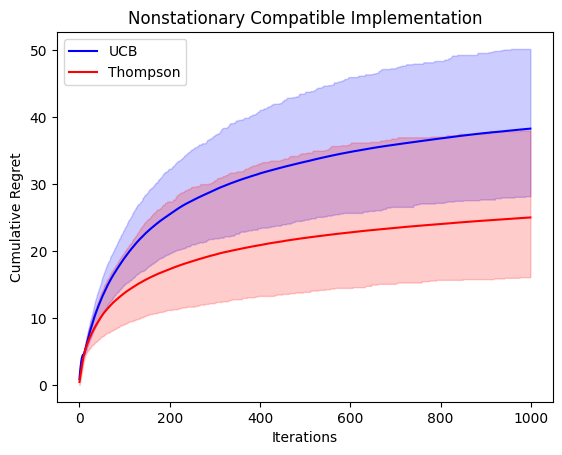

In [9]:
T, K, sigma = 200, 5, 1

#array = np.tile(np.arange(0.1, 1.1, 0.1), (1000, 1)).T

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='UCB', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

regrets = np.zeros((1000, T))
standard_priors = np.tile(np.array([0, 10]), (K, 1))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    regrets[sim] = np.cumsum(ThompsonSampling_Gaussian(bandits_env, standard_priors, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='Thompson', color='r')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='r')

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    regrets[sim] = np.cumsum(UniformSampling(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='Uniform Sampling', color='g')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='g')

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Nonstationary Compatible Implementation')
plt.show()

### (c)

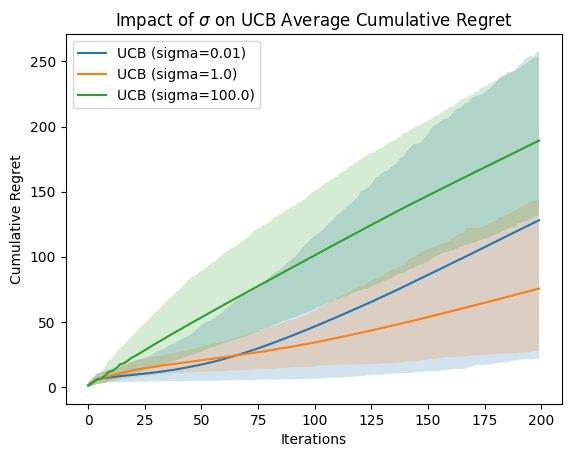

In [9]:
T, K = 200, 5
sigmas = [0.01, 1.0, 100.0]

for sigma in sigmas:
    regrets = np.zeros((1000, T))
    for sim in range(1000):
        mean_rewards = generate_mean_rewards()
        bandits_env = GetArms(K, mean_rewards, sigma)
        for arm in bandits_env:
            setattr(arm, 'ucb', 1000.0)
            setattr(arm, 'lcb', -1000.0)
        regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
    mean_regrets = np.mean(regrets, axis=0)
    sorted_regrets = np.sort(regrets, axis=0)
    CB95 = sorted_regrets[949]
    CB5 = sorted_regrets[49]
    plt.plot(mean_regrets, label=f'UCB (sigma={sigma})')
    plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2)

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title(r'Impact of $\sigma$ on UCB Average Cumulative Regret')
plt.savefig('2c_1', dpi=300)

0.01
0.03162277660168379
0.1
0.31622776601683794
1.0
3.1622776601683795
10.0
31.622776601683793
100.0


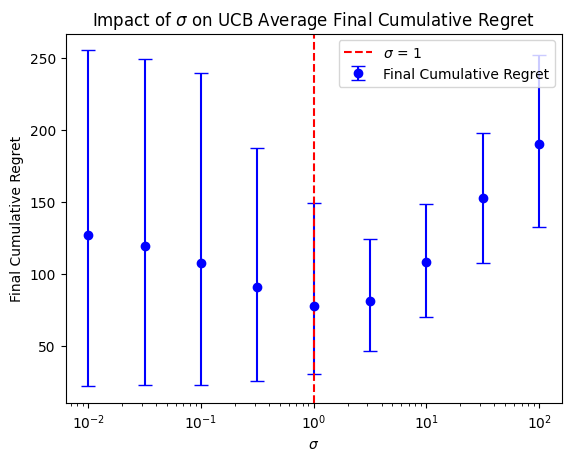

In [12]:
T, K = 200, 5
sigmas = np.logspace(-2, 2, num=9)
final_mean_regrets = []
upper_bounds = []
lower_bounds = []

for sigma in sigmas:
    regrets = np.zeros((1000, T))
    for sim in range(1000):
        mean_rewards = generate_mean_rewards()
        bandits_env = GetArms(K, mean_rewards, sigma)
        for arm in bandits_env:
            setattr(arm, 'ucb', 1000.0)
            setattr(arm, 'lcb', -1000.0)
        regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
    
    # Compute final cumulative regret at the last time point
    final_regrets = regrets[:, -1]
    mean_final_regret = np.mean(final_regrets)
    sorted_final_regrets = np.sort(final_regrets)
    CB95 = sorted_final_regrets[949]  # 95th percentile
    CB5 = sorted_final_regrets[49]    # 5th percentile
    
    # Store the results for plotting
    final_mean_regrets.append(mean_final_regret)
    upper_bounds.append(CB95)
    lower_bounds.append(CB5)

# Plotting sigma vs final cumulative regret
plt.errorbar(sigmas, final_mean_regrets, 
             yerr=[np.array(final_mean_regrets) - np.array(lower_bounds), 
                   np.array(upper_bounds) - np.array(final_mean_regrets)], 
             fmt='o', capsize=5, color='b', label='Final Cumulative Regret')

# Add a red dashed line at sigma = 1
plt.axvline(x=1.0, linestyle='--', color='r', label=r'$\sigma$ = 1')

plt.xscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel('Final Cumulative Regret')
plt.title(r'Impact of $\sigma$ on UCB Average Final Cumulative Regret')
plt.legend()
plt.savefig('2c_2.png', dpi=300)

### (e)

In [34]:
def Rexp3(arms, T, gamma, delta_T):
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    # 1
    j = 1
    # 2
    while j <= np.ceil(T / delta_T):
        # 2 (a)
        tau = (j - 1) * delta_T
        # 2 (b)
        ws = np.ones(K)
        # 2 (c)
        for t in range(tau + 1, min(T, tau + delta_T) + 1):
            # 2 (c) i
            ps = (1 - gamma) * (ws / np.sum(ws)) + (gamma / K)
            # 2 (c) ii
            arm_index = np.random.choice(K, p=ps)
            arm = arms[arm_index]
            # 2 (c) iii
            # NOTE: We must use index t - 1 for consistency
            rew[t - 1] = arm.play(t - 1)
            reg[t - 1] = max(myarm.mu_t_a[t-1] for myarm in arms) - arm.mu_t_a[t-1]
            # 2 (c) iv
            adjusted_reward = rew[t - 1] / ps[arm_index]
            for k in range(K):
                if k == arm_index:
                    ws[k] *= np.exp(gamma * adjusted_reward / K)
                else:
                    ws[k] *= 1.0
        # 2 (d)
        j += 1
    return rew, reg

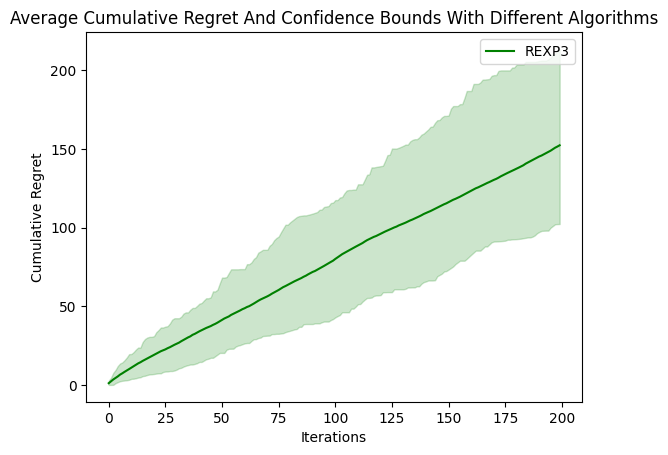

In [35]:
K, T, noise_var = 5, 200, 1
# Parameters for REXP3
#gamma, delta_T = 0.5, 100
gamma, delta_T = 0.5, 100

array = np.tile(np.arange(0, 21, 5), (1000, 1)).T

regrets_rexp3 = np.zeros((100, T))
for sim in range(100):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    regrets_rexp3[sim] = np.cumsum(Rexp3(bandits_env, T, gamma, delta_T)[1])
mean_regrets_rexp3 = np.mean(regrets_rexp3, axis=0)
sorted_regrets_rexp3 = np.sort(regrets_rexp3, axis=0)
CB95_rexp3 = sorted_regrets_rexp3[94]
CB5_rexp3 = sorted_regrets_rexp3[4]
plt.plot(mean_regrets_rexp3, label='REXP3', color='g')
plt.fill_between(np.arange(T), CB5_rexp3, CB95_rexp3, alpha=0.2, color='g')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret And Confidence Bounds With Different Algorithms')
plt.show()

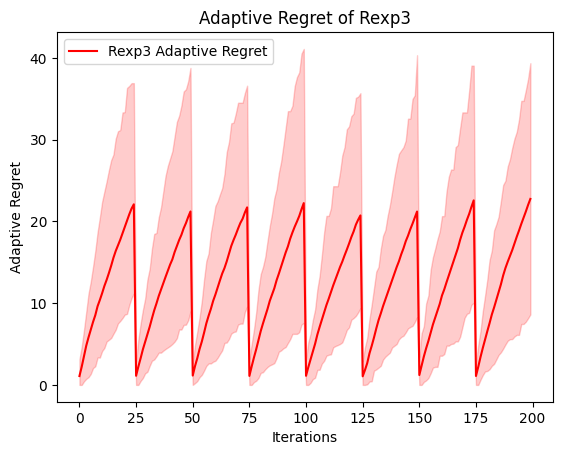

In [40]:
# Set parameters
T, K, sigma, gamma, delta_T = 200, 5, 1, 0.5, 25
window_size = delta_T  # Adaptive regret will reset every delta_T steps

# Initialize arrays for adaptive regrets
adaptive_regrets_rexp3 = np.zeros((100, T))

for sim in range(100):
    # Generate environment with nonstationary rewards
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    
    # Calculate regret using Rexp3 in adaptive windows
    all_regret = Rexp3(bandits_env, T, gamma, delta_T)[1]  # Get the regret per step
    adaptive_regret = np.zeros(T)  # Initialize an array for adaptive regret
    
    # Calculate adaptive regret in windows
    for t in range(0, T, window_size):
        # Compute regret for the current window
        window_end = min(t + window_size, T)
        window_regret = np.cumsum(all_regret[t:window_end])
        # Store window regret, reset at each window start
        adaptive_regret[t:window_end] = window_regret
    
    # Store the adaptive regret for this simulation
    adaptive_regrets_rexp3[sim] = adaptive_regret

# Calculate mean and confidence intervals for adaptive regrets
mean_adaptive_regret = np.mean(adaptive_regrets_rexp3, axis=0)
sorted_adaptive_regrets = np.sort(adaptive_regrets_rexp3, axis=0)
CB95 = sorted_adaptive_regrets[94]  # 95th percentile
CB5 = sorted_adaptive_regrets[4]    # 5th percentile

# Plot adaptive regret with confidence intervals
plt.plot(mean_adaptive_regret, label='Rexp3 Adaptive Regret', color='r')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='r')
plt.xlabel('Iterations')
plt.ylabel('Adaptive Regret')
plt.title('Adaptive Regret of Rexp3')
plt.legend(loc='upper left')
plt.show()

### (f)

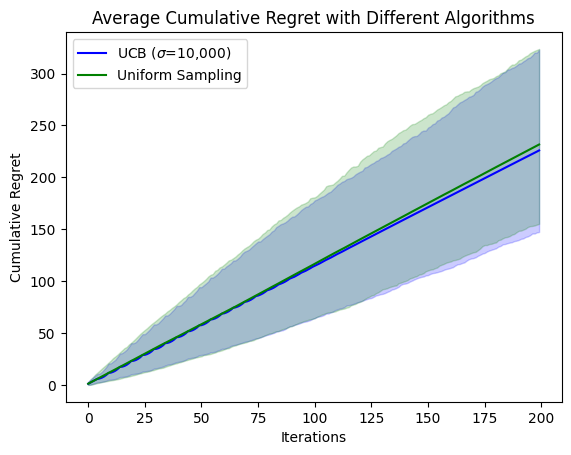

In [13]:
T, K, sigma = 200, 5, 10000

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label=r'UCB ($\sigma$=10,000)', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

regrets = np.zeros((1000, T))
for sim in range(1000):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    regrets[sim] = np.cumsum(UniformSampling(bandits_env, T)[1])
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[949]
CB5 = sorted_regrets[49]
plt.plot(mean_regrets, label='Uniform Sampling', color='g')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='g')

plt.legend(loc='upper left')
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret with Different Algorithms')
plt.savefig('2f_1.png', dpi=300)